<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/LogisticRegression_Ansh_CS23185.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
path="/content/drive/MyDrive/ML/BreastCancer.csv"
data=pd.read_csv(path)

In [5]:
print(data.head())
print(data.shape)
print(data.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [6]:
data = data.drop(['id', 'Unnamed: 32'], axis=1)

In [7]:
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})

In [8]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

In [12]:
for split in [0.2, 0.3]:

    print("\n==============================")
    print(f"Split: {int((1-split)*100)}-{int(split*100)}")
    print("==============================")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Model
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Split: 80-20
Accuracy: 0.9736842105263158
[[70  1]
 [ 2 41]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Split: 70-30
Accuracy: 0.9824561403508771
[[106   2]
 [  1  62]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171




ROC Curve for Split: 80-20


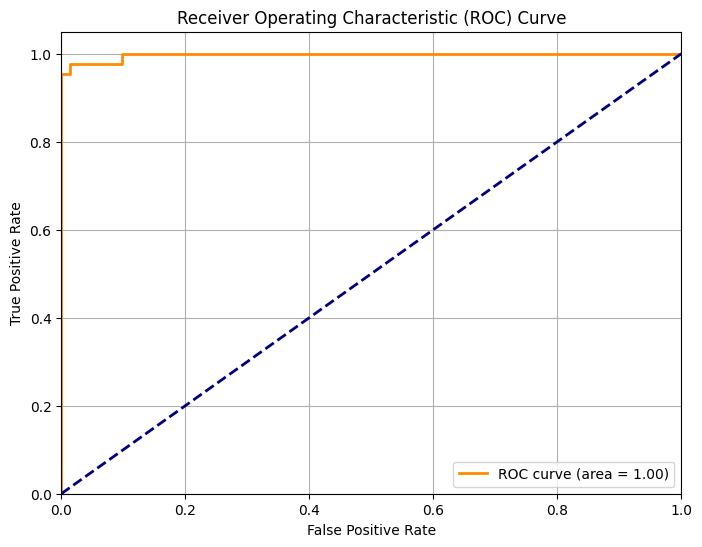


ROC Curve for Split: 70-30


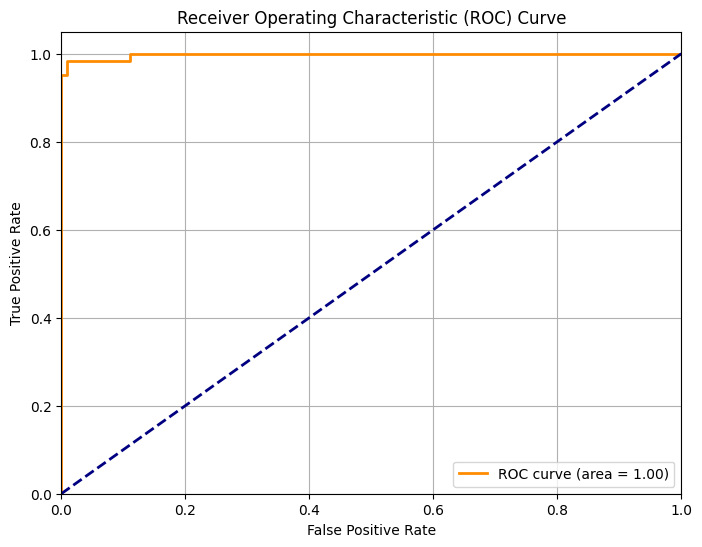

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

for split in [0.2, 0.3]:
    print(f"\n==============================")
    print(f"ROC Curve for Split: {int((1-split)*100)}-{int(split*100)}")
    print(f"==============================")

    # Split data again to get X_test and y_test for current split iteration
    X_train_roc, X_test_roc, y_train_roc, y_test_roc = train_test_split(
        X, y, test_size=split, random_state=42
    )

    # Scale data again for current split iteration
    scaler_roc = StandardScaler()
    X_train_roc = scaler_roc.fit_transform(X_train_roc)
    X_test_roc = scaler_roc.transform(X_test_roc)

    # Train model again for current split iteration
    model_roc = LogisticRegression()
    model_roc.fit(X_train_roc, y_train_roc)

    # Predict probabilities for the positive class
    y_prob_roc = model_roc.predict_proba(X_test_roc)[:, 1]

    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_roc, y_prob_roc)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()